# GEMS and GEOS-CF TCO diurnal variability check

This notebook keeps the workflow focused on total column ozone (`totcol_o3` / `ColumnAmountO3`).
NO2 code is kept only as an optional reference cell and is disabled by default.


In [3]:
import sys
from pathlib import Path

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Shared analysis settings
GEOS_CF_CHEM_URL = "https://opendap.nccs.nasa.gov/dods/gmao/geos-cf/assim/xgc_tavg_1hr_g1440x721_x1"
TARGET_VAR = "totcol_o3"
TARGET_DATE = "2024-07-14"
YEAR = "2024"
MONTH = 7
LAT_RANGE = [-3.0, 2.0]
LON_RANGE = [121.0, 131.0]

OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Settings:")
print(f"  date      : {TARGET_DATE}")
print(f"  region    : lat {LAT_RANGE}, lon {LON_RANGE}")
print(f"  GEOS-CF   : {TARGET_VAR}")


Settings:
  date      : 2024-07-14
  region    : lat [-3.0, 2.0], lon [121.0, 131.0]
  GEOS-CF   : totcol_o3


## Optional NO2 reference

This cell is kept because NO2 may be useful later, but it is skipped by default so the notebook runs as a TCO-only analysis.
Set `RUN_NO2_REFERENCE = True` if you want to inspect GEOS-CF total column NO2.


In [4]:
RUN_NO2_REFERENCE = False

if RUN_NO2_REFERENCE:
    ds_ref = xr.open_dataset(GEOS_CF_CHEM_URL)
    no2_ref = ds_ref["totcol_no2"].sel(
        time=TARGET_DATE,
        lat=slice(20, 50),
        lon=slice(100, 150),
    )
    no2_ref.mean(dim="time").plot()
    plt.title(f"GEOS-CF total column NO2 reference, {TARGET_DATE}")
    plt.show()
else:
    print("Skipping NO2 reference cell. Set RUN_NO2_REFERENCE=True to run it.")


Skipping NO2 reference cell. Set RUN_NO2_REFERENCE=True to run it.


## GEOS-CF TCO for one day

This checks hourly total column ozone over the same domain on 2024-07-14.
The variability metric is the spatial standard deviation after removing the hourly spatial mean, matching the GEMS diagnostic idea.


In [ ]:
print(f"Opening GEOS-CF: {GEOS_CF_CHEM_URL}")
ds_geos = xr.open_dataset(GEOS_CF_CHEM_URL)

geos_tco_day = ds_geos[TARGET_VAR].sel(
    time=slice(f"{TARGET_DATE}T00:00:00", f"{TARGET_DATE}T23:59:59"),
    lat=slice(LAT_RANGE[0], LAT_RANGE[1]),
    lon=slice(LON_RANGE[0], LON_RANGE[1]),
).load()

print(geos_tco_day)

geos_space_mean = geos_tco_day.mean(dim=["lat", "lon"], skipna=True)
geos_residual = geos_tco_day - geos_space_mean
geos_residual_std = geos_residual.std(dim=["lat", "lon"], skipna=True)
geos_spatial_std = geos_tco_day.std(dim=["lat", "lon"], skipna=True)

geos_day_summary = pd.DataFrame({
    "time_utc": pd.to_datetime(geos_space_mean["time"].values),
    "hour_utc": pd.to_datetime(geos_space_mean["time"].values).hour,
    "mean_tco": geos_space_mean.values,
    "spatial_std": geos_spatial_std.values,
    "residual_std": geos_residual_std.values,
})

print(geos_day_summary.to_string(index=False))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"GEOS-CF TCO - {TARGET_DATE} ({LON_RANGE[0]:.0f}-{LON_RANGE[1]:.0f}E, {LAT_RANGE[0]:.0f}-{LAT_RANGE[1]:.0f}N)",
    fontsize=13,
    fontweight="bold",
)

hours = geos_day_summary["hour_utc"].values

axes[0].plot(hours, geos_day_summary["mean_tco"].values, marker="o", lw=2.5, color="steelblue")
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Total column O3")
axes[0].set_title("Spatial mean TCO")
axes[0].set_xticks(hours)
axes[0].grid(True, alpha=0.3)

axes[1].plot(hours, geos_day_summary["spatial_std"].values, marker="o", lw=2.5, color="firebrick", label="Spatial std")
axes[1].plot(hours, geos_day_summary["residual_std"].values, marker="s", lw=2.0, color="darkorange", linestyle="--", label="Residual std")
axes[1].set_xlabel("Hour (UTC)")
axes[1].set_ylabel("Std across grid cells")
axes[1].set_title("Hourly spatial heterogeneity")
axes[1].set_xticks(hours)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / f"geos_cf_tco_hourly_heterogeneity_{TARGET_DATE}.png", dpi=130, bbox_inches="tight")
plt.show()


## GEOS-CF TCO July 2024 hourly spatial variability

This matches the GEMS `Analysis 4` style from `hourly_variability_sources_041326.ipynb`: compute spatial variance at each timestamp, then average those variances by UTC hour across July days. No extra temporal detrending or spatial trend removal is applied.


In [ ]:
# GEOS-CF July-wide hourly spatial variability, matching GEMS Analysis 4 logic:
#   for each timestamp: Var_space(TCO)
#   then by UTC hour: mean over July days
# Note: std(Y - mean_space(Y)) == std(Y), so no separate detrending is needed for variance.

geos_tco_july = ds_geos[TARGET_VAR].sel(
    time=slice(f"{YEAR}-{MONTH:02d}-01T00:00:00", f"{YEAR}-{MONTH:02d}-31T23:59:59"),
    lat=slice(LAT_RANGE[0], LAT_RANGE[1]),
    lon=slice(LON_RANGE[0], LON_RANGE[1]),
).load()

geos_july_space_mean_ts = geos_tco_july.mean(dim=["lat", "lon"], skipna=True)
geos_july_space_std_ts = geos_tco_july.std(dim=["lat", "lon"], skipna=True)
geos_july_space_var_ts = geos_july_space_std_ts ** 2

geos_july_hourly_mean = geos_july_space_mean_ts.groupby(geos_july_space_mean_ts.time.dt.hour).mean(skipna=True)
geos_july_hourly_spatial_var = geos_july_space_var_ts.groupby(geos_july_space_var_ts.time.dt.hour).mean(skipna=True)
geos_july_hourly_spatial_std = np.sqrt(geos_july_hourly_spatial_var)

geos_july_summary = pd.DataFrame({
    "hour_utc": geos_july_hourly_mean["hour"].values.astype(int),
    "local_time_approx": (geos_july_hourly_mean["hour"].values + np.mean(LON_RANGE) / 15.0) % 24,
    "mean_tco": geos_july_hourly_mean.values,
    "mean_spatial_var": geos_july_hourly_spatial_var.values,
    "sqrt_mean_spatial_var": geos_july_hourly_spatial_std.values,
})

print(geos_july_summary.to_string(index=False))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"GEOS-CF TCO - July {YEAR} hourly mean spatial variability ({LON_RANGE[0]:.0f}-{LON_RANGE[1]:.0f}E, {LAT_RANGE[0]:.0f}-{LAT_RANGE[1]:.0f}N)",
    fontsize=13,
    fontweight="bold",
)

hours = geos_july_summary["hour_utc"].values
local_hours = geos_july_summary["local_time_approx"].values

axes[0].plot(hours, geos_july_summary["mean_tco"].values, marker="o", lw=2.5, color="steelblue")
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Total column O3")
axes[0].set_title("July mean spatial-mean TCO")
axes[0].set_xticks(hours)
axes[0].grid(True, alpha=0.3)

axes[1].plot(hours, geos_july_summary["mean_spatial_var"].values, marker="o", lw=2.5, color="firebrick")
axes[1].set_xlabel("Hour (UTC)")
axes[1].set_ylabel("Mean spatial variance")
axes[1].set_title("E_day[Var_space(TCO)] by hour")
axes[1].set_xticks(hours)
axes[1].grid(True, alpha=0.3)

# Top-axis local solar time approximation for the region center longitude.
top = axes[1].secondary_xaxis('top')
top.set_xticks(hours)
top.set_xticklabels([f"{h:.0f}" for h in local_hours], fontsize=8)
top.set_xlabel("Approx local solar time")

peak_idx = int(np.nanargmax(geos_july_summary["mean_spatial_var"].values))
peak_hour = int(geos_july_summary.loc[peak_idx, "hour_utc"])
peak_local = geos_july_summary.loc[peak_idx, "local_time_approx"]
peak_val = geos_july_summary.loc[peak_idx, "mean_spatial_var"]
axes[1].annotate(
    f"peak {peak_hour} UTC\n~{peak_local:.1f} local",
    xy=(peak_hour, peak_val),
    xytext=(peak_hour + 1.0, peak_val),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", lw=1.0),
)

plt.tight_layout()
plt.savefig(OUT_DIR / f"geos_cf_tco_july{YEAR}_hourly_spatial_var.png", dpi=130, bbox_inches="tight")
plt.show()


## GEMS TCO July 2024 slot-wise variability

This computes the corresponding GEMS diagnostic for July 2024 over the same domain.
For each GEMS observation slot and day, it removes the spatial mean and pools the residuals by slot.


In [ ]:
sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed

loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, _ = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=10,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=False,
)

sorted_keys = sorted(df_map.keys())
n_days = len(sorted_keys) // 8
print(f"GEMS July {YEAR}: {n_days} complete days inferred from {len(sorted_keys)} slots")

slot_residuals = {t: [] for t in range(8)}
slot_smeans = {t: [] for t in range(8)}
slot_hours = {t: [] for t in range(8)}  # UTC hour-of-day, from Hours_elapsed % 24

for d_idx in range(n_days):
    day_keys = sorted_keys[d_idx * 8 : (d_idx + 1) * 8]

    for slot, key in enumerate(day_keys):
        df = df_map[key]
        tmp = pd.DataFrame({
            "o3": pd.to_numeric(df["ColumnAmountO3"], errors="coerce"),
            "hour": pd.to_numeric(df["Hours_elapsed"], errors="coerce"),
        }).dropna()

        if tmp.empty:
            continue

        y_bar_td = tmp["o3"].mean()
        r_td = tmp["o3"] - y_bar_td

        slot_residuals[slot].extend(r_td.tolist())
        slot_smeans[slot].append(y_bar_td)
        slot_hours[slot].append(float(tmp["hour"].median() % 24))

rows = []
for slot in range(8):
    r = np.array(slot_residuals[slot], dtype=float)
    m = np.array(slot_smeans[slot], dtype=float)
    h = np.array(slot_hours[slot], dtype=float)
    rows.append({
        "slot": slot,
        "hour_utc": np.nan if len(h) == 0 else h.mean(),
        "n_residuals": len(r),
        "n_days": len(m),
        "mean_ybar": np.nan if len(m) == 0 else m.mean(),
        "sigma_t": np.nan if len(r) <= 1 else r.std(ddof=1),
        "var_t": np.nan if len(r) <= 1 else r.var(ddof=1),
    })

gems_slot_summary = pd.DataFrame(rows)
ratio = gems_slot_summary["sigma_t"].max() / gems_slot_summary["sigma_t"].min()

print(gems_slot_summary.to_string(index=False))
print(f"Max/min sigma ratio: {ratio:.2f}x; variance ratio: {ratio**2:.1f}x")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"GEMS TCO - Diurnal spatial heterogeneity ({LON_RANGE[0]:.0f}-{LON_RANGE[1]:.0f}E, {LAT_RANGE[0]:.0f}-{LAT_RANGE[1]:.0f}N, July {YEAR})",
    fontsize=13,
    fontweight="bold",
)

hours = gems_slot_summary["hour_utc"].values
sigma = gems_slot_summary["sigma_t"].values
mean_ybar = gems_slot_summary["mean_ybar"].values

axes[0].plot(hours, mean_ybar, color="steelblue", lw=2.5, marker="o", label="Spatial mean")
axes[0].fill_between(hours, mean_ybar - sigma, mean_ybar + sigma, color="steelblue", alpha=0.2, label="+/- sigma_t")
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("TCO (DU)")
axes[0].set_title("Spatial mean and residual spread")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].bar(gems_slot_summary["slot"].values, sigma, color="firebrick", alpha=0.7)
axes[1].set_xticks(gems_slot_summary["slot"].values)
axes[1].set_xticklabels([f"S{slot}\n({hour:.0f}h)" for slot, hour in zip(gems_slot_summary["slot"], hours)], fontsize=9)
axes[1].set_xlabel("GEMS slot")
axes[1].set_ylabel("sigma_t (DU)")
axes[1].set_title("Per-slot residual std")
axes[1].grid(True, alpha=0.3)
axes[1].text(
    0.05,
    0.95,
    f"Max/min sigma: {ratio:.2f}x\nVar ratio: {ratio**2:.1f}x",
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

plt.tight_layout()
plt.savefig(OUT_DIR / f"gems_tco_diurnal_sigma_july{YEAR}.png", dpi=130, bbox_inches="tight")
plt.show()


## GEMS TCO July 2024 Analysis 4: E_day[Var_space(h)]

This matches the `Analysis 4` definition from `hourly_variability_sources_041326.ipynb`: for each GEMS day and slot, compute the spatial variance of `ColumnAmountO3`, then average those spatial variances by slot. This is the GEMS-side quantity that is most directly comparable to the GEOS-CF July `E_day[Var_space(TCO)]` diagnostic above.


In [20]:
# GEMS Analysis 4 style: E_day[Var_space(h)] for July 2024.
# Use ddof=0 to match xarray.std/var defaults used in the GEOS-CF cells.
# If you want the exact pandas default from the older notebook, change ddof to 1.
VAR_DDOF = 0

gems_spatial_records = []
for d_idx in range(n_days):
    day_keys = sorted_keys[d_idx * 8 : (d_idx + 1) * 8]

    for slot, key in enumerate(day_keys):
        df = df_map[key]
        tmp = pd.DataFrame({
            "o3": pd.to_numeric(df["ColumnAmountO3"], errors="coerce"),
            "hour": pd.to_numeric(df["Hours_elapsed"], errors="coerce"),
        }).dropna()

        if len(tmp) <= VAR_DDOF:
            continue

        spatial_mean = tmp["o3"].mean()
        spatial_var = tmp["o3"].var(ddof=VAR_DDOF)
        spatial_std = np.sqrt(spatial_var)
        hours_elapsed = float(tmp["hour"].median())
        hour_utc = hours_elapsed % 24

        gems_spatial_records.append({
            "day_idx": d_idx,
            "slot": slot,
            "hour_utc": hour_utc,
            "spatial_mean": spatial_mean,
            "spatial_var": spatial_var,
            "spatial_std": spatial_std,
            "n_obs": len(tmp),
        })

gems_spatial_df = pd.DataFrame(gems_spatial_records)

gems_analysis4_summary = (
    gems_spatial_df
    .groupby("slot")
    .agg(
        hour_utc=("hour_utc", "mean"),
        n_days=("day_idx", "nunique"),
        mean_spatial_mean=("spatial_mean", "mean"),
        mean_spatial_var=("spatial_var", "mean"),
        sqrt_mean_spatial_var=("spatial_var", lambda x: float(np.sqrt(np.mean(x)))),
        mean_spatial_std=("spatial_std", "mean"),
        mean_n_obs=("n_obs", "mean"),
    )
    .reset_index()
)

print(gems_analysis4_summary.to_string(index=False))


 slot  hour_utc  n_days  mean_spatial_mean  mean_spatial_var  sqrt_mean_spatial_var  mean_spatial_std   mean_n_obs
    0  0.883333      31         258.419048         13.826992               3.718466          3.683199 18065.322581
    1  1.883333      31         257.925795         15.722960               3.965219          3.932281 17708.419355
    2  2.883333      31         257.159922         16.390459               4.048513          4.010603 17183.838710
    3  3.883333      31         256.918535         16.897492               4.110656          4.070043 17213.193548
    4  4.800000      31         257.100139         16.830094               4.102450          4.065990 17300.322581
    5  5.800000      31         257.773135         17.617581               4.197330          4.165573 17708.322581
    6  6.800000      31         258.301764         15.046731               3.879012          3.842702 18099.129032
    7  7.800000      31         260.281265         13.286722               3.645

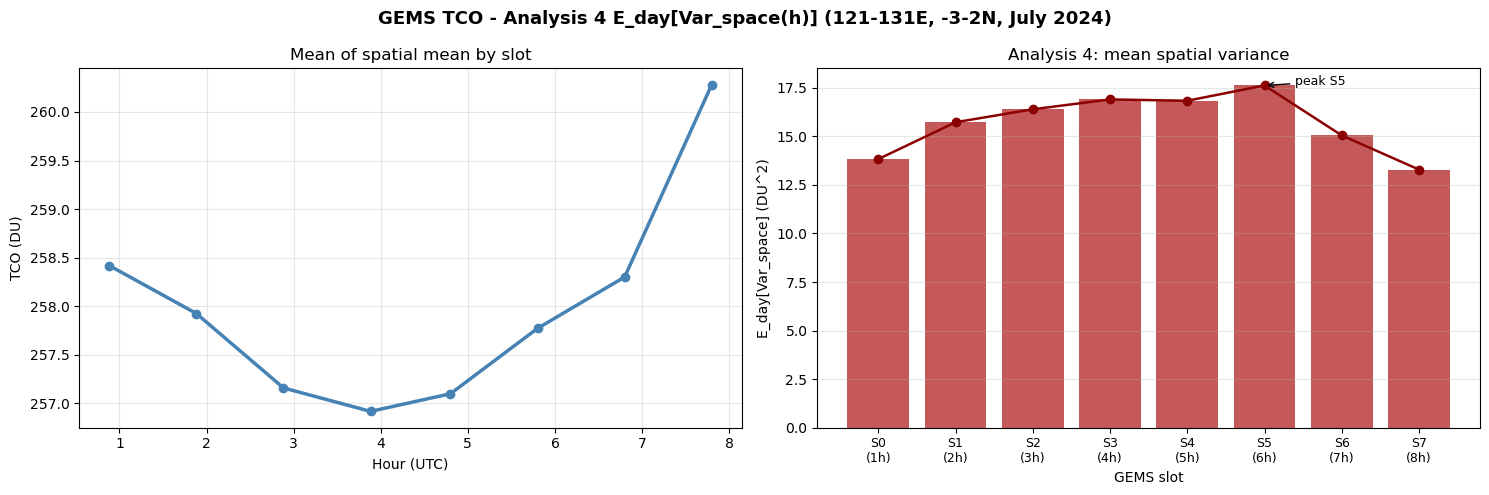

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"GEMS TCO - Analysis 4 E_day[Var_space(h)] ({LON_RANGE[0]:.0f}-{LON_RANGE[1]:.0f}E, {LAT_RANGE[0]:.0f}-{LAT_RANGE[1]:.0f}N, July {YEAR})",
    fontsize=13,
    fontweight="bold",
)

slots = gems_analysis4_summary["slot"].values
hours = gems_analysis4_summary["hour_utc"].values
mean_var = gems_analysis4_summary["mean_spatial_var"].values

axes[0].plot(hours, gems_analysis4_summary["mean_spatial_mean"].values, marker="o", lw=2.5, color="steelblue")
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("TCO (DU)")
axes[0].set_title("Mean of spatial mean by slot")
axes[0].grid(True, alpha=0.3)

axes[1].bar(slots, mean_var, color="firebrick", alpha=0.75)
axes[1].plot(slots, mean_var, marker="o", lw=1.8, color="darkred")
axes[1].set_xticks(slots)
axes[1].set_xticklabels([f"S{slot}\n({hour:.0f}h)" for slot, hour in zip(slots, hours)], fontsize=9)
axes[1].set_xlabel("GEMS slot")
axes[1].set_ylabel("E_day[Var_space] (DU^2)")
axes[1].set_title("Analysis 4: mean spatial variance")
axes[1].grid(True, axis="y", alpha=0.3)

peak_idx = int(np.nanargmax(mean_var))
axes[1].annotate(
    f"peak S{slots[peak_idx]}",
    xy=(slots[peak_idx], mean_var[peak_idx]),
    xytext=(slots[peak_idx] + 0.4, mean_var[peak_idx]),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", lw=1.0),
)

plt.tight_layout()
#plt.savefig(OUT_DIR / f"gems_tco_analysis4_july{YEAR}.png", dpi=130, bbox_inches="tight")
plt.show()


## Quick comparison note

Use the GEOS-CF one-day plot to check whether physical model TCO has an hourly increase in spatial heterogeneity around the same time of day as GEMS.
A stricter comparison would repeat the GEOS-CF calculation across all July days and sample only the hours closest to the GEMS observation slots.


## Apparent TCO advection from sequential maps

This estimates the apparent movement of the TCO spatial pattern between consecutive maps. It is not a direct meteorological wind measurement. The reported vector is the direction the TCO pattern moves toward; `wind_from_deg` is the opposite direction, using the usual wind-from convention.


In [1]:
# Apparent advection helpers.
# Convention: positive v_lat_kmh is northward, positive v_lon_kmh is eastward.
# bearing_to_deg is the direction the TCO pattern moves toward, clockwise from north.

MAX_SHIFT_PIXELS = 6
MIN_VALID_PIXELS = 64


def _wrapped_lags(n):
    idx = np.arange(n)
    return np.where(idx <= n // 2, idx, idx - n)


def phase_correlation_shift(previous_map, next_map, max_shift_pixels=MAX_SHIFT_PIXELS, min_valid_pixels=MIN_VALID_PIXELS):
    """Return the integer grid shift that moves previous_map toward next_map."""
    a = np.asarray(previous_map, dtype=float)
    b = np.asarray(next_map, dtype=float)
    valid = np.isfinite(a) & np.isfinite(b)

    if valid.sum() < min_valid_pixels:
        return {
            "row_shift": np.nan,
            "col_shift": np.nan,
            "peak_corr": np.nan,
            "valid_pixels": int(valid.sum()),
        }

    a0 = np.zeros_like(a, dtype=float)
    b0 = np.zeros_like(b, dtype=float)
    a0[valid] = a[valid] - np.nanmean(a[valid])
    b0[valid] = b[valid] - np.nanmean(b[valid])

    # Windowing makes the phase-correlation peak less dominated by map boundaries.
    wy = np.hanning(a.shape[0]) if a.shape[0] > 1 else np.ones(a.shape[0])
    wx = np.hanning(a.shape[1]) if a.shape[1] > 1 else np.ones(a.shape[1])
    window = np.outer(wy, wx)
    a0 *= window
    b0 *= window

    fa = np.fft.fft2(a0)
    fb = np.fft.fft2(b0)
    cross_power = fb * np.conj(fa)
    cross_power /= np.maximum(np.abs(cross_power), 1e-12)
    corr = np.fft.ifft2(cross_power).real

    if max_shift_pixels is not None:
        row_lags = _wrapped_lags(corr.shape[0])
        col_lags = _wrapped_lags(corr.shape[1])
        allowed = (np.abs(row_lags)[:, None] <= max_shift_pixels) & (np.abs(col_lags)[None, :] <= max_shift_pixels)
        corr = np.where(allowed, corr, -np.inf)

    peak = np.unravel_index(np.nanargmax(corr), corr.shape)
    row_shift = int(_wrapped_lags(corr.shape[0])[peak[0]])
    col_shift = int(_wrapped_lags(corr.shape[1])[peak[1]])

    return {
        "row_shift": row_shift,
        "col_shift": col_shift,
        "peak_corr": float(corr[peak]),
        "valid_pixels": int(valid.sum()),
    }


def shift_to_velocity(row_shift, col_shift, lat_vals, lon_vals, dt_hours):
    lat_vals = np.asarray(lat_vals, dtype=float)
    lon_vals = np.asarray(lon_vals, dtype=float)
    dt_hours = float(dt_hours)

    if not np.isfinite(row_shift) or not np.isfinite(col_shift) or not np.isfinite(dt_hours) or dt_hours <= 0:
        return {
            "dlat_deg": np.nan,
            "dlon_deg": np.nan,
            "v_lat_kmh": np.nan,
            "v_lon_kmh": np.nan,
            "speed_kmh": np.nan,
            "bearing_to_deg": np.nan,
            "wind_from_deg": np.nan,
        }

    lat_step = float(np.nanmedian(np.diff(lat_vals))) if len(lat_vals) > 1 else np.nan
    lon_step = float(np.nanmedian(np.diff(lon_vals))) if len(lon_vals) > 1 else np.nan
    lat_center = float(np.nanmean(lat_vals))

    dlat_deg = row_shift * lat_step
    dlon_deg = col_shift * lon_step
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat_center))

    v_lat_kmh = dlat_deg * km_per_deg_lat / dt_hours
    v_lon_kmh = dlon_deg * km_per_deg_lon / dt_hours
    speed_kmh = float(np.hypot(v_lat_kmh, v_lon_kmh))
    bearing_to_deg = float((np.degrees(np.arctan2(v_lon_kmh, v_lat_kmh)) + 360.0) % 360.0)
    wind_from_deg = float((bearing_to_deg + 180.0) % 360.0)

    return {
        "dlat_deg": float(dlat_deg),
        "dlon_deg": float(dlon_deg),
        "v_lat_kmh": float(v_lat_kmh),
        "v_lon_kmh": float(v_lon_kmh),
        "speed_kmh": speed_kmh,
        "bearing_to_deg": bearing_to_deg,
        "wind_from_deg": wind_from_deg,
    }


def compass_label(deg):
    if not np.isfinite(deg):
        return "NA"
    labels = np.array(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
    return str(labels[int(((deg + 22.5) % 360) // 45)])


def summarize_advection_vectors(records, group_cols):
    df = pd.DataFrame(records)
    if df.empty:
        return df

    grouped = (
        df.dropna(subset=["v_lat_kmh", "v_lon_kmh"])
        .groupby(group_cols, dropna=False)
        .agg(
            n_pairs=("v_lat_kmh", "size"),
            mean_v_lat_kmh=("v_lat_kmh", "mean"),
            mean_v_lon_kmh=("v_lon_kmh", "mean"),
            median_speed_kmh=("speed_kmh", "median"),
            mean_peak_corr=("peak_corr", "mean"),
            median_valid_pixels=("valid_pixels", "median"),
        )
        .reset_index()
    )
    grouped["vector_mean_speed_kmh"] = np.hypot(grouped["mean_v_lat_kmh"], grouped["mean_v_lon_kmh"])
    grouped["bearing_to_deg"] = (np.degrees(np.arctan2(grouped["mean_v_lon_kmh"], grouped["mean_v_lat_kmh"])) + 360.0) % 360.0
    grouped["wind_from_deg"] = (grouped["bearing_to_deg"] + 180.0) % 360.0
    grouped["toward_compass"] = grouped["bearing_to_deg"].map(compass_label)
    grouped["wind_from_compass"] = grouped["wind_from_deg"].map(compass_label)
    return grouped


def plot_advection_summary(summary_df, title, out_path):
    if summary_df.empty:
        print(f"No advection rows to plot for {title}.")
        return

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.axhline(0, color="0.75", lw=1)
    ax.axvline(0, color="0.75", lw=1)

    colors = plt.cm.tab10(np.linspace(0, 1, max(len(summary_df), 1)))
    max_speed = max(float(summary_df["vector_mean_speed_kmh"].max()), 1.0)

    for color, (_, row) in zip(colors, summary_df.iterrows()):
        label_bits = []
        for col in ["source", "slot_pair", "time_pair"]:
            if col in row.index and pd.notna(row[col]):
                label_bits.append(str(row[col]))
        label = " / ".join(label_bits) if label_bits else "mean vector"
        ax.arrow(
            0,
            0,
            row["mean_v_lon_kmh"],
            row["mean_v_lat_kmh"],
            color=color,
            width=max_speed * 0.006,
            head_width=max_speed * 0.05,
            length_includes_head=True,
            alpha=0.85,
            label=label,
        )

    lim = max_speed * 1.2
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Eastward component (km/hour)")
    ax.set_ylabel("Northward component (km/hour)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()


Loading geos_tco_day because it is not already in memory.


/opt/anaconda3/envs/faiss_env/lib/python3.12/site-packages/xarray/coding/times.py:206: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


GEOS-CF apparent advection summary
 source  n_pairs  mean_v_lat_kmh  mean_v_lon_kmh  median_speed_kmh  mean_peak_corr  median_valid_pixels  vector_mean_speed_kmh  bearing_to_deg  wind_from_deg toward_compass wind_from_compass
GEOS-CF       23             0.0             0.0               0.0        0.631436                861.0                    0.0             0.0          180.0              N                 S
Saved pair-level rows to /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/geos_cf_tco_apparent_advection_2024-07-14_lat-3.0_2.0_lon121.0_131.0.csv
Saved summary to /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/geos_cf_tco_apparent_advection_summary_2024-07-14_lat-3.0_2.0_lon121.0_131.0.csv


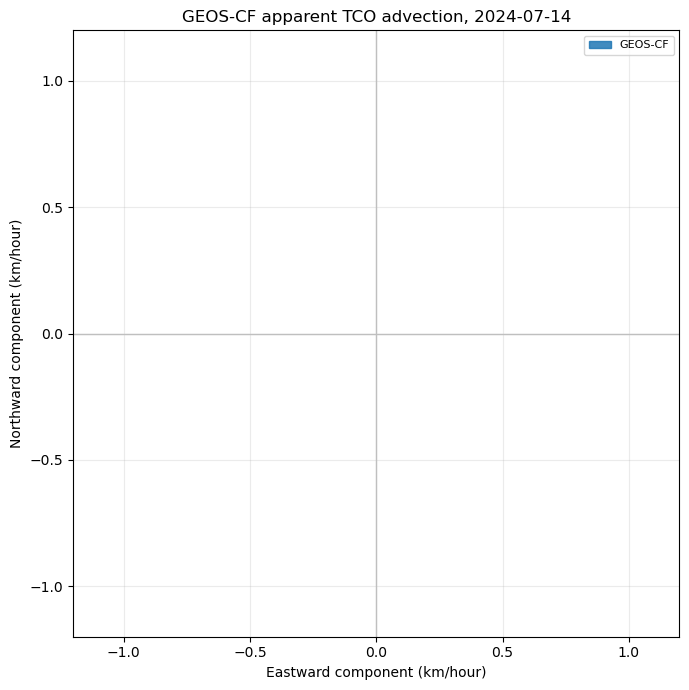

In [5]:
# GEOS-CF apparent advection for the selected day.
# This uses hourly GEOS-CF TCO maps over the current LAT_RANGE/LON_RANGE.

if "geos_tco_day" not in globals():
    print("Loading geos_tco_day because it is not already in memory.")
    ds_geos = xr.open_dataset(GEOS_CF_CHEM_URL)
    geos_tco_day = ds_geos[TARGET_VAR].sel(
        time=slice(f"{TARGET_DATE}T00:00:00", f"{TARGET_DATE}T23:59:59"),
        lat=slice(LAT_RANGE[0], LAT_RANGE[1]),
        lon=slice(LON_RANGE[0], LON_RANGE[1]),
    ).load()

geos_records = []
geos_times = pd.to_datetime(geos_tco_day["time"].values)
geos_lat = geos_tco_day["lat"].values
geos_lon = geos_tco_day["lon"].values

for k in range(len(geos_times) - 1):
    t0 = geos_times[k]
    t1 = geos_times[k + 1]
    dt_hours = (t1 - t0) / pd.Timedelta(hours=1)

    previous_map = geos_tco_day.isel(time=k).values
    next_map = geos_tco_day.isel(time=k + 1).values

    shift = phase_correlation_shift(previous_map, next_map)
    velocity = shift_to_velocity(shift["row_shift"], shift["col_shift"], geos_lat, geos_lon, dt_hours)

    geos_records.append({
        "source": "GEOS-CF",
        "time0_utc": t0,
        "time1_utc": t1,
        "time_pair": f"{t0.hour:02d}-{t1.hour:02d} UTC",
        "dt_hours": float(dt_hours),
        **shift,
        **velocity,
    })

geos_advection_df = pd.DataFrame(geos_records)
geos_summary = summarize_advection_vectors(geos_records, ["source"])
geos_timepair_summary = summarize_advection_vectors(geos_records, ["source", "time_pair"])

geos_advection_path = OUT_DIR / f"geos_cf_tco_apparent_advection_{TARGET_DATE}_lat{LAT_RANGE[0]}_{LAT_RANGE[1]}_lon{LON_RANGE[0]}_{LON_RANGE[1]}.csv"
geos_summary_path = OUT_DIR / f"geos_cf_tco_apparent_advection_summary_{TARGET_DATE}_lat{LAT_RANGE[0]}_{LAT_RANGE[1]}_lon{LON_RANGE[0]}_{LON_RANGE[1]}.csv"
geos_advection_df.to_csv(geos_advection_path, index=False)
geos_summary.to_csv(geos_summary_path, index=False)

print("GEOS-CF apparent advection summary")
print(geos_summary.to_string(index=False))
print(f"Saved pair-level rows to {geos_advection_path}")
print(f"Saved summary to {geos_summary_path}")

plot_advection_summary(
    geos_summary,
    f"GEOS-CF apparent TCO advection, {TARGET_DATE}",
    OUT_DIR / f"geos_cf_tco_apparent_advection_vector_{TARGET_DATE}.png",
)


--- Global Monthly Mean for 2024-7: 257.9726 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
GEMS apparent advection overall summary
source  n_pairs  mean_v_lat_kmh  mean_v_lon_kmh  median_speed_kmh  mean_peak_corr  median_valid_pixels  vector_mean_speed_kmh  bearing_to_deg  wind_from_deg toward_compass wind_from_compass
  GEMS      217        0.022572       -7.568182               0.0         0.08106              17785.0               7.568216      270.170882      90.170882              W                 E

GEMS apparent advection by slot pair
source slot_pair  n_pairs  mean_v_lat_kmh  mean_v_lon_kmh  median_speed_kmh  mean_peak_corr  median_valid_pixels  vector_mean_speed_kmh  bearing_to_deg  wind_from_deg toward_compass wind_from_compass
  GEMS     S0-S1       31        0.316005       -4.298234           0.00000        0.057308              17934.0               4.309834      274.204808      94.204808              W                 E
  GEMS     S1-S2       31        1.2

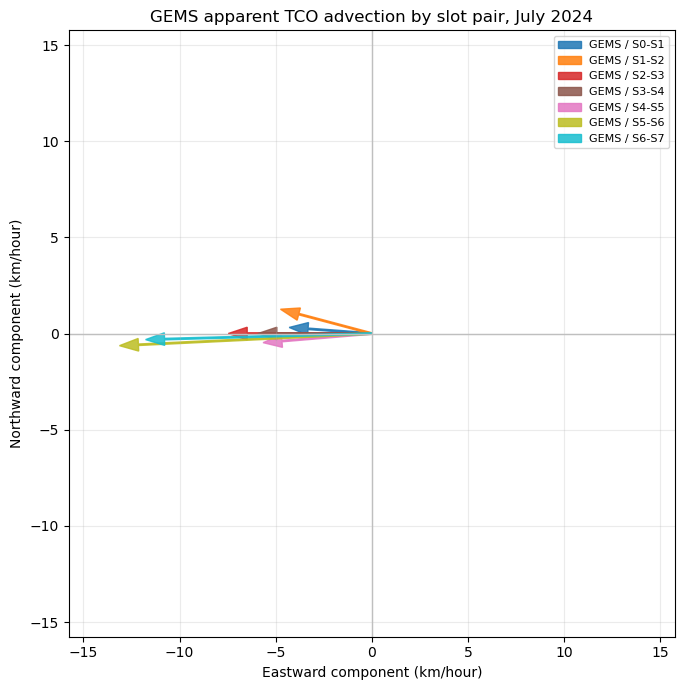

In [6]:
# GEMS apparent advection from consecutive daily slots.
# This estimates slot-to-slot movement of the TCO pattern within each day, then averages by slot pair.

if "df_map" not in globals():
    sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
    from GEMS_TCO import configuration as config
    from GEMS_TCO.data_loader import load_data_dynamic_processed

    loader = load_data_dynamic_processed(config.mac_data_load_path)
    df_map, _, _, _ = loader.load_maxmin_ordered_data_bymonthyear(
        lat_lon_resolution=[1, 1],
        mm_cond_number=10,
        years_=[YEAR],
        months_=[MONTH],
        lat_range=LAT_RANGE,
        lon_range=LON_RANGE,
        is_whittle=False,
    )


def gems_frame_to_grid(df):
    tmp = df[["Latitude", "Longitude", "ColumnAmountO3", "Hours_elapsed"]].copy()
    tmp["Latitude"] = pd.to_numeric(tmp["Latitude"], errors="coerce")
    tmp["Longitude"] = pd.to_numeric(tmp["Longitude"], errors="coerce")
    tmp["ColumnAmountO3"] = pd.to_numeric(tmp["ColumnAmountO3"], errors="coerce")
    tmp["Hours_elapsed"] = pd.to_numeric(tmp["Hours_elapsed"], errors="coerce")
    tmp = tmp.dropna(subset=["Latitude", "Longitude", "ColumnAmountO3"])

    grid = tmp.pivot_table(
        index="Latitude",
        columns="Longitude",
        values="ColumnAmountO3",
        aggfunc="mean",
    ).sort_index().sort_index(axis=1)

    hour = float(tmp["Hours_elapsed"].median()) if tmp["Hours_elapsed"].notna().any() else np.nan
    return grid.values, grid.index.values.astype(float), grid.columns.values.astype(float), hour


sorted_keys = sorted(df_map.keys())
n_days = len(sorted_keys) // 8
gems_records = []

for d_idx in range(n_days):
    day_keys = sorted_keys[d_idx * 8 : (d_idx + 1) * 8]
    if len(day_keys) < 2:
        continue

    day_grids = [gems_frame_to_grid(df_map[key]) for key in day_keys]

    for slot in range(len(day_grids) - 1):
        previous_map, lat0, lon0, hour0 = day_grids[slot]
        next_map, lat1, lon1, hour1 = day_grids[slot + 1]

        # The loader should provide the same regular grid for every slot in this region.
        # If a slot is missing some rows/columns, skip rather than silently comparing different grids.
        if previous_map.shape != next_map.shape or not np.array_equal(lat0, lat1) or not np.array_equal(lon0, lon1):
            continue

        dt_hours = hour1 - hour0
        if not np.isfinite(dt_hours) or dt_hours <= 0:
            continue

        shift = phase_correlation_shift(previous_map, next_map)
        velocity = shift_to_velocity(shift["row_shift"], shift["col_shift"], lat0, lon0, dt_hours)

        gems_records.append({
            "source": "GEMS",
            "day_idx": d_idx,
            "slot0": slot,
            "slot1": slot + 1,
            "slot_pair": f"S{slot}-S{slot + 1}",
            "hour0_utc": hour0 % 24,
            "hour1_utc": hour1 % 24,
            "dt_hours": float(dt_hours),
            **shift,
            **velocity,
        })

gems_advection_df = pd.DataFrame(gems_records)
gems_summary = summarize_advection_vectors(gems_records, ["source"])
gems_slotpair_summary = summarize_advection_vectors(gems_records, ["source", "slot_pair"])

gems_advection_path = OUT_DIR / f"gems_tco_apparent_advection_july{YEAR}_lat{LAT_RANGE[0]}_{LAT_RANGE[1]}_lon{LON_RANGE[0]}_{LON_RANGE[1]}.csv"
gems_summary_path = OUT_DIR / f"gems_tco_apparent_advection_summary_july{YEAR}_lat{LAT_RANGE[0]}_{LAT_RANGE[1]}_lon{LON_RANGE[0]}_{LON_RANGE[1]}.csv"
gems_advection_df.to_csv(gems_advection_path, index=False)
gems_slotpair_summary.to_csv(gems_summary_path, index=False)

print("GEMS apparent advection overall summary")
print(gems_summary.to_string(index=False))
print("\nGEMS apparent advection by slot pair")
print(gems_slotpair_summary.to_string(index=False))
print(f"Saved pair-level rows to {gems_advection_path}")
print(f"Saved slot-pair summary to {gems_summary_path}")

plot_advection_summary(
    gems_slotpair_summary,
    f"GEMS apparent TCO advection by slot pair, July {YEAR}",
    OUT_DIR / f"gems_tco_apparent_advection_slot_vectors_july{YEAR}.png",
)


 source  n_pairs  mean_v_lat_kmh  mean_v_lon_kmh  median_speed_kmh  mean_peak_corr  median_valid_pixels  vector_mean_speed_kmh  bearing_to_deg  wind_from_deg toward_compass wind_from_compass
GEOS-CF       23        0.000000        0.000000               0.0        0.631436                861.0               0.000000        0.000000     180.000000              N                 S
   GEMS      217        0.022572       -7.568182               0.0        0.081060              17785.0               7.568216      270.170882      90.170882              W                 E
Saved combined summary to /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/tco_apparent_advection_combined_summary_lat-3.0_2.0_lon121.0_131.0.csv


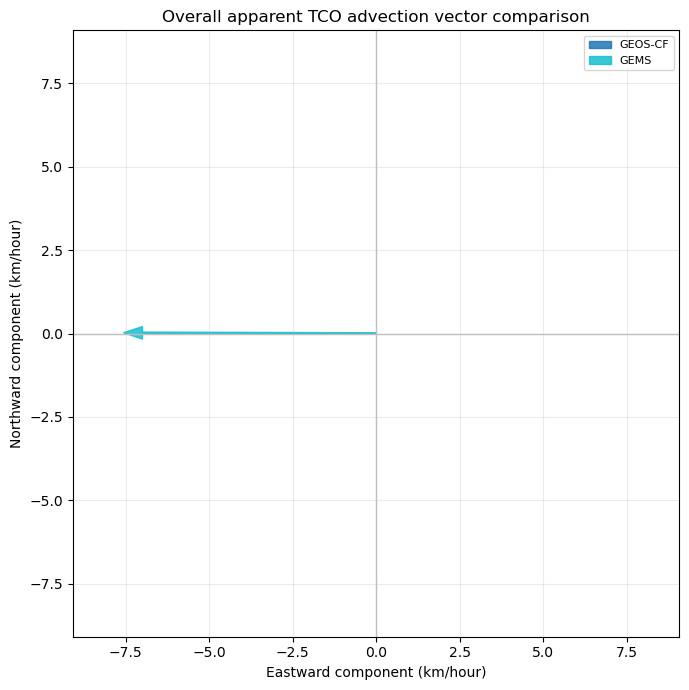

In [7]:
# Combined GEOS-CF/GEMS vector summary.

summary_parts = []
if "geos_summary" in globals() and not geos_summary.empty:
    summary_parts.append(geos_summary)
if "gems_summary" in globals() and not gems_summary.empty:
    summary_parts.append(gems_summary)

if summary_parts:
    combined_advection_summary = pd.concat(summary_parts, ignore_index=True)
    combined_path = OUT_DIR / f"tco_apparent_advection_combined_summary_lat{LAT_RANGE[0]}_{LAT_RANGE[1]}_lon{LON_RANGE[0]}_{LON_RANGE[1]}.csv"
    combined_advection_summary.to_csv(combined_path, index=False)
    print(combined_advection_summary.to_string(index=False))
    print(f"Saved combined summary to {combined_path}")

    plot_advection_summary(
        combined_advection_summary,
        "Overall apparent TCO advection vector comparison",
        OUT_DIR / "tco_apparent_advection_overall_vectors.png",
    )
else:
    print("Run the GEOS-CF and/or GEMS advection cells first.")
